In [1]:
import numpy as np
from dictlearn import DictionaryLearning
from dictlearn import methods
from matplotlib import image
from sklearn.feature_extraction.image import extract_patches_2d, reconstruct_from_patches_2d
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

In [2]:
p = 8
s = 6
N = 1000
n = 256 # numarul de atomi din dictionar
K = 50 # numarul de iteratii DL
sigma = 0.075 # deviatia standard a zgomotului

In [3]:
def psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 0
    max_pixel = 255
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

# Ex1

### a.

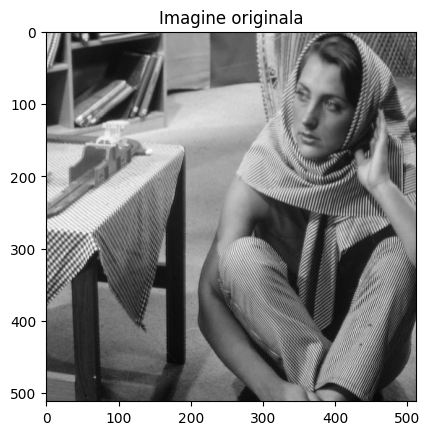

In [4]:
I = image.imread('barbara.png')

plt.imshow(I, cmap='gray')
plt.title("Imagine originala")
plt.show()

### b.

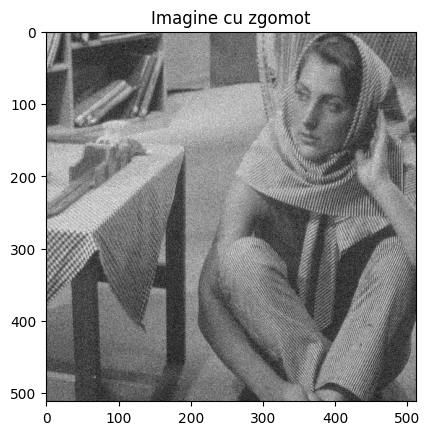

In [5]:
Inoisy = I + sigma * np.random.randn(I.shape[0], I.shape[1])

plt.imshow(Inoisy, cmap='gray')
plt.title("Imagine cu zgomot")
plt.show()

### c.

In [6]:
Ynoisy = extract_patches_2d(Inoisy, (p, p))
print("Dimensiunea initiala a patch-urilor:", Ynoisy.shape)

Ynoisy = Ynoisy.reshape(Ynoisy.shape[0], -1)
print("Dimensiunea dupa vectorizare:", Ynoisy.shape)

Ynoisy = Ynoisy.T
media_patch = np.mean(Ynoisy, axis=0)
Ynoisy -= media_patch

Dimensiunea initiala a patch-urilor: (255025, 8, 8)
Dimensiunea dupa vectorizare: (255025, 64)


### d.

In [7]:
indices = np.random.choice(Ynoisy.shape[1], N, replace=False)
Y = Ynoisy[:, indices]

# Ex2

### a.

In [8]:
D0 = np.random.randn(p * p, n)
D0 = normalize(D0, axis=0, norm='max')

### b.

In [9]:
dl = DictionaryLearning(
    n_components=n,
    max_iter=K,
    fit_algorithm='ksvd',
    n_nonzero_coefs=s,
    code_init=None,
    dict_init=D0,
    params=None,
    data_sklearn_compat=False
)
dl.fit(Y)
D = dl.D_

/home/cosmin/anaconda3/lib/python3.11/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


# Ex3

### a.

In [10]:
Xc, err = methods.omp(Ynoisy, D, n_nonzero_coefs=6)

### b.

In [11]:
Yc = D @ Xc
Yc += media_patch

### c.

In [12]:
Yc = Yc.T
Yc = Yc.reshape(-1, p, p)
Ic = reconstruct_from_patches_2d(Yc, I.shape)

# Ex 4

### a.

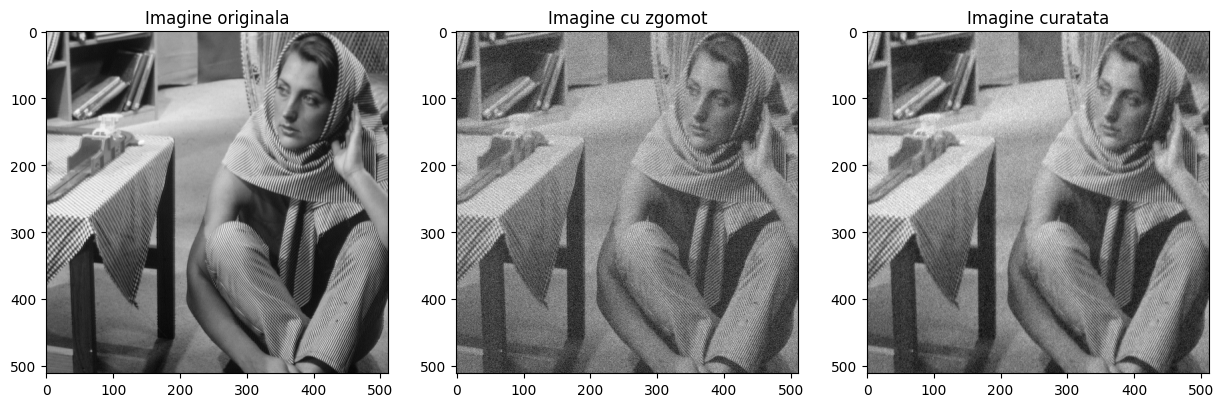

In [13]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(I, cmap='gray')
plt.title("Imagine originala")

plt.subplot(1, 3, 2)
plt.imshow(Inoisy, cmap='gray')
plt.title("Imagine cu zgomot")

plt.subplot(1, 3, 3)
plt.imshow(Ic, cmap='gray')
plt.title("Imagine curatata")
plt.show()

### b.

In [14]:
psnr_noisy = psnr(I, Inoisy)
psnr_cleaned = psnr(I, Ic)
print(f"PSNR (noisy vs original): {psnr_noisy:.2f}")
print(f"PSNR (cleaned vs original): {psnr_cleaned:.2f}")

PSNR (noisy vs original): 70.62
PSNR (cleaned vs original): 75.12
